In [1]:
import numpy as np
import matplotlib.pyplot as plt
from openai import OpenAI
import os
from dotenv import load_dotenv
import wikipedia
import bs4
import functools
from itertools import combinations
import time
import string
import random
import nltk
from collections import Counter

In [2]:
# Load NLTK data
nltk.download('brown')
nltk.download('punkt')

[nltk_data] Downloading package brown to /Users/yd211/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt to /Users/yd211/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [9]:
from nltk.corpus import brown
from nltk.probability import FreqDist
from nltk.tokenize import word_tokenize

load_dotenv()

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))


In [4]:
def create_random_chars(n, min_length=20, max_length=100):
    """
    Generate n sentences composed of random characters.
    Each sentence has a random length between min_length and max_length.
    """
    sentences = []
    for _ in range(n):
        length = random.randint(min_length, max_length)
        sentence = ''.join(random.choices(string.ascii_letters + string.digits + string.punctuation + ' ', k=length))
        sentences.append(sentence)
    return sentences

print(create_random_chars(3))

['X00Ql(_%M-.ZCB8y,pAg5xGYX1u5o8PvB@cf$MpH+=~3hW6$((LPz?VZ', ';>R>&&iNpWB$\\? I{wdEdC_/QbC', 'dwZj[}aS6l]|Bt!X\\e\\w']


In [6]:
def create_random_words(n, min_words=6, max_words=18):
    """
    Generate n sentences composed of random English words based on frequency.
    Each sentence has a random number of words between min_words and max_words.
    """
    # Build frequency distribution from Brown Corpus
    words = brown.words()
    fdist = FreqDist(word.lower() for word in words if word.isalpha())
    vocabulary, frequencies = zip(*fdist.items())
    frequencies = np.array(frequencies, dtype=np.float64)
    probabilities = frequencies / frequencies.sum()
    
    sentences = []
    for _ in range(n):
        num_words = random.randint(min_words, max_words)
        selected_words = np.random.choice(vocabulary, size=num_words, replace=True, p=probabilities)
        sentence = ' '.join(selected_words)
        sentences.append(sentence)
    return sentences


print(create_random_words(3))

['secret the her rocky collaboration and mind power but hart off drive in his', 'linked and and the he badinage russian even or she are had and and counseling that what with', 'nation what brackets which impatient late western who and then very the van']


In [7]:
def create_random_meaningful_sentences(n):
    """
    Generate n grammatically correct and semantically meaningful sentences
    sampled randomly from the Brown Corpus.
    """
    # Extract all sentences from the Brown Corpus
    all_sentences = brown.sents()
    # Convert list of word tokens to sentences
    sentences = [' '.join(sentence) for sentence in all_sentences if len(sentence) >= 5]  # Filter short sentences
    # Sample n random sentences
    sampled_sentences = random.sample(sentences, n)
    return sampled_sentences

print(create_random_meaningful_sentences(3))

['In view of these difficulties , Palfrey decided to go to Louisiana .', "This has not , however , prevented publishers from labeling him a `` folk poet '' , simply because he is a rural one .", 'Whether this , or overt action , was the cause of the crash must be promptly determined .']


3072
Computed magnitudes for 4 sentences
Computed 6 angles
[33.465085   80.23903801 80.83549494 80.13127511 82.05517367 79.81106793]


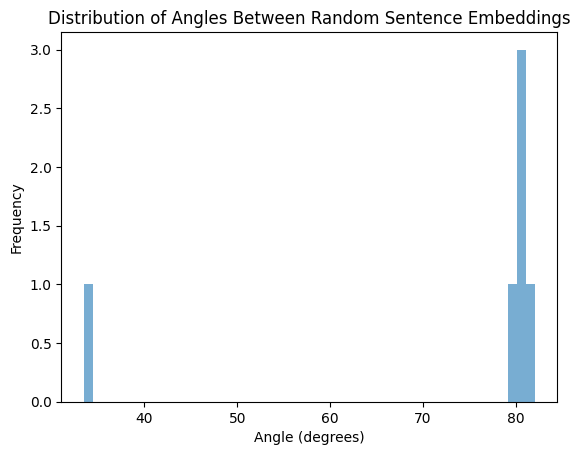

In [23]:
# def embed_text(text):
#     response = client.embeddings.create(
#         model="text-embedding-3-large",
#         input=text
#     )
    
#     return response.data[0].embedding

a = ["I am a sentence", "I am another sentence", "Louis was happy", "Ronalado plays socer"]

print(len(embed_text(a[0])))

def get_embeddings(text: list[str]):
    return [embed_text(sentence) for sentence in text]

b = get_embeddings(a)

def get_angles(embeddings):

    # Calculate magnitudes once
    magnitudes = np.array([np.linalg.norm(emb) for emb in embeddings])
    print(f"Computed magnitudes for {len(magnitudes)} sentences")
    
    # Compute pairwise dot products and angles directly
    angles = []
    for i in range(len(embeddings)):
        for j in range(i+1, len(embeddings)):
            dp = np.dot(embeddings[i], embeddings[j])
            # Calculate angle directly using dot product and magnitudes
            cos_theta = np.clip(dp / (magnitudes[i] * magnitudes[j]), -1.0, 1.0)
            angle = np.degrees(np.arccos(cos_theta))
            angles.append(angle)
            
    print(f"Computed {len(angles)} angles")
    
    return np.array(angles)

c = get_angles(b)

print(c)    
    
def plot_embedding_angles(angles):
    plt.hist(angles, bins=50, alpha=0.6)
    plt.title("Distribution of Angles Between Random Sentence Embeddings")
    plt.xlabel("Angle (degrees)")
    plt.ylabel("Frequency")
    plt.show()
    
plot_embedding_angles(c)

generated sentences
embedded sentences
Computed magnitudes for 100 sentences
Computed 4950 angles
Computed magnitudes for 100 sentences
Computed 4950 angles
Computed magnitudes for 100 sentences
Computed 4950 angles
calculated angles


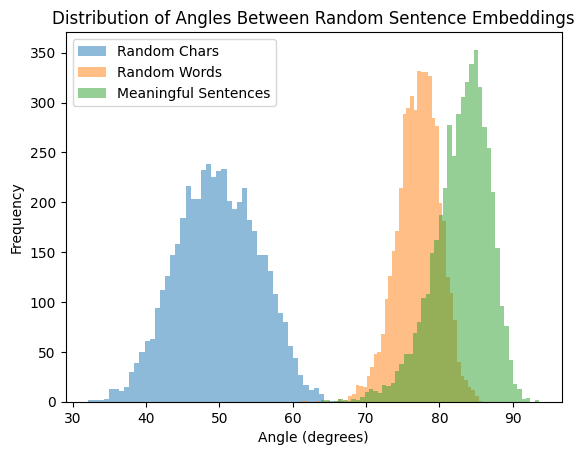

In [ ]:
n = 100

# Generate random sentences
char_sentences = create_random_chars(n)
word_sentences = create_random_words(n)
meaningful_sentences = create_random_meaningful_sentences(n)

print("generated sentences")

# Embed sentences
char_embeddings = get_embeddings(char_sentences)
word_embeddings = get_embeddings(word_sentences)
meaningful_embeddings = get_embeddings(meaningful_sentences)

print("embedded sentences")

# Calculate angles
char_angles = get_angles(char_embeddings)
word_angles = get_angles(word_embeddings)
meaningful_angles = get_angles(meaningful_embeddings)

print("calculated angles")

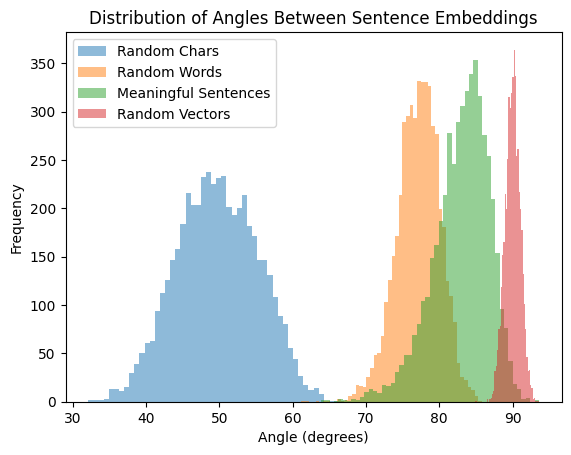

In [24]:
# Generate random vectors and calculate angles
random_vectors = np.random.randn(n, 3072)
random_embeddings = random_vectors / np.linalg.norm(random_vectors, axis=1, keepdims=True)
random_angles = []
for i in range(n):
    for j in range(i + 1, n):
        angle = np.degrees(np.arccos(np.clip(np.dot(random_embeddings[i], random_embeddings[j]), -1.0, 1.0)))
        random_angles.append(angle)

# Plot distributions
plt.hist(char_angles, bins=50, alpha=0.5, label='Random Chars')
plt.hist(word_angles, bins=50, alpha=0.5, label='Random Words')
plt.hist(meaningful_angles, bins=50, alpha=0.5, label='Meaningful Sentences')
plt.hist(random_angles, bins=50, alpha=0.5, label='Random Vectors')
plt.title("Distribution of Angles Between Sentence Embeddings")
plt.xlabel("Angle (degrees)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [27]:
# printing mean and variance

print('Mean:')
print(f"Random Charachters: {np.mean(char_angles):.2f} degrees")
print(f"Random Words: {np.mean(word_angles):.2f} degrees")
print(f"Meaningful Sentences: {np.mean(meaningful_angles):.2f} degrees")
print(f"Random Vectors: {np.mean(random_angles):.2f} degrees \n\n")

print('Variance:')
print(f"Random Charachters: {np.var(char_angles):.2f} degrees")
print(f"Random Words: {np.var(word_angles):.2f} degrees")
print(f"Meaningful Sentences: {np.var(meaningful_angles):.2f} degrees")
print(f"Random Vectors: {np.var(random_angles):.2f} degrees")



Mean:
Random Charachters: 49.74 degrees
Random Words: 77.13 degrees
Meaningful Sentences: 82.96 degrees
Random Vectors: 90.00 degrees 


Variance:
Random Charachters: 30.87 degrees
Random Words: 8.59 degrees
Meaningful Sentences: 14.75 degrees
Random Vectors: 1.06 degrees
